In [1]:
# MVP analysis version1
# 000001, 000300, 601318, 600900, 601899

In [3]:
import efinance as ef
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)


In [19]:
selected_stocks = {
    "601318": "Ping An Insurance",
    "600900": "China Yangtze Power",
    "601899": "Zijin Mining",
}

index_ids = {
    "000001": "SSE Composite",
    "000300": "CSI 300",
}

beg = "20230101"
end = "20260401"


In [20]:
def clean_price_df(df):
    tmp = df.copy()
    tmp["日期"] = pd.to_datetime(tmp["日期"])
    
    numeric_cols = ["开盘", "收盘", "最高", "最低", "成交量", "成交额", "涨跌幅", "涨跌额", "换手率"]
    for col in numeric_cols:
        if col in tmp.columns:
            tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    
    tmp = tmp.sort_values("日期").drop_duplicates(subset=["日期"]).reset_index(drop=True)
    return tmp


In [21]:
def add_features(df):
    tmp = df.copy()
    
    tmp["MA20"] = tmp["收盘"].rolling(20).mean()
    tmp["MA60"] = tmp["收盘"].rolling(60).mean()
    tmp["MA120"] = tmp["收盘"].rolling(120).mean()
    tmp["MA250"] = tmp["收盘"].rolling(250).mean()
    
    tmp["return_20d"] = tmp["收盘"] / tmp["收盘"].shift(20) - 1
    tmp["return_60d"] = tmp["收盘"] / tmp["收盘"].shift(60) - 1
    tmp["return_120d"] = tmp["收盘"] / tmp["收盘"].shift(120) - 1
    
    return tmp


In [22]:
def label_trend(df):
    tmp = df.copy()
    
    latest = tmp.iloc[-1]
    
    price = latest["收盘"]
    ma20 = latest["MA20"]
    ma60 = latest["MA60"]
    ma120 = latest["MA120"]
    ret60 = latest["return_60d"]
    ret120 = latest["return_120d"]
    
    if pd.notna(ma20) and pd.notna(ma60) and pd.notna(ma120) and pd.notna(ret60) and pd.notna(ret120):
        if price > ma20 > ma60 > ma120 and ret60 > 0 and ret120 > 0:
            return "上升趋势"
        elif price < ma20 < ma60 and ret60 < 0:
            return "走弱"
        else:
            return "震荡"
    return "数据不足"


In [23]:
index_data = {}

for code, name in index_ids.items():
    df = ef.stock.get_quote_history(
        code,
        beg=beg,
        end=end,
        klt=101,
        fqt=1,
    )
    df = clean_price_df(df)
    df = add_features(df)
    index_data[code] = df
    print(code, name, df.shape)


000001 SSE Composite (784, 20)
000300 CSI 300 (784, 20)


In [24]:
stock_data = {}

for code, name in selected_stocks.items():
    df = ef.stock.get_quote_history(
        code,
        beg=beg,
        end=end,
        klt=101,
        fqt=1,
    )
    df = clean_price_df(df)
    df = add_features(df)
    stock_data[code] = df
    print(code, name, df.shape)


601318 Ping An Insurance (784, 20)
600900 China Yangtze Power (784, 20)
601899 Zijin Mining (784, 20)


In [25]:
for code, df in index_data.items():
    print("=" * 60)
    print(code, index_ids[code])
    display(df[["日期", "收盘", "MA20", "MA60", "MA120", "MA250", "return_20d", "return_60d", "return_120d"]].tail())


000001 SSE Composite


,日期,收盘,MA20,MA60,MA120,MA250,return_20d,return_60d,return_120d
779,2026-03-26,10.94,10.8535,11.079500,11.283500,11.33416,0.006440,-0.050347,-0.024086
780,2026-03-27,11.02,10.8595,11.070500,11.282500,11.33464,0.011009,-0.046713,-0.010772
781,2026-03-30,10.99,10.8665,11.061333,11.280083,11.33504,0.012903,-0.047660,-0.025709
782,2026-03-31,11.08,10.8765,11.053333,11.278917,11.33568,0.018382,-0.041522,-0.012478
783,2026-04-01,11.10,10.8960,11.046000,11.278417,11.33652,0.036415,-0.038128,-0.005376


000300 CSI 300


,日期,收盘,MA20,MA60,MA120,MA250,return_20d,return_60d,return_120d
779,2026-03-26,4477.53,4619.1355,4676.591000,4635.705750,4318.36100,-0.052749,-0.029077,-0.005418
780,2026-03-27,4502.57,4608.7315,4674.621667,4635.538750,4320.38412,-0.044172,-0.025572,-0.004431
781,2026-03-30,4491.95,4596.8955,4672.253167,4635.306833,4322.32104,-0.050061,-0.030666,-0.006157
782,2026-03-31,4450.05,4586.6030,4669.045000,4634.340000,4324.08056,-0.044213,-0.041462,-0.025409
783,2026-04-01,4498.04,4581.3740,4666.391667,4633.544583,4326.17276,-0.022722,-0.034183,-0.020779


In [26]:
for code, df in stock_data.items():
    print("=" * 60)
    print(code, selected_stocks[code])
    display(df[["日期", "收盘", "MA20", "MA60", "MA120", "MA250", "return_20d", "return_60d", "return_120d"]].tail())


601318 Ping An Insurance


,日期,收盘,MA20,MA60,MA120,MA250,return_20d,return_60d,return_120d
779,2026-03-26,56.80,60.9570,65.377000,62.307083,57.61684,-0.105512,-0.171287,0.048938
780,2026-03-27,56.95,60.6500,65.168000,62.330000,57.64132,-0.097321,-0.180458,0.050738
781,2026-03-30,56.33,60.3490,64.956333,62.348833,57.66180,-0.096552,-0.183978,0.041798
782,2026-03-31,56.78,60.0595,64.722667,62.369167,57.68284,-0.092536,-0.198023,0.044902
783,2026-04-01,57.71,59.8555,64.498500,62.398917,57.71392,-0.066030,-0.189011,0.065940


600900 China Yangtze Power


,日期,收盘,MA20,MA60,MA120,MA250,return_20d,return_60d,return_120d
779,2026-03-26,27.31,27.1200,26.716333,27.272583,27.86104,0.048771,-0.000732,0.011856
780,2026-03-27,27.25,27.1805,26.712000,27.275417,27.86432,0.046467,-0.009451,0.012635
781,2026-03-30,27.14,27.2090,26.707167,27.275667,27.86784,0.021453,-0.010572,0.001107
782,2026-03-31,27.04,27.2125,26.700667,27.275667,27.86924,0.002595,-0.014218,0.000000
783,2026-04-01,26.92,27.2040,26.692167,27.274333,27.87012,-0.006275,-0.018593,-0.005908


601899 Zijin Mining


,日期,收盘,MA20,MA60,MA120,MA250,return_20d,return_60d,return_120d
779,2026-03-26,32.09,35.5925,36.853667,33.299083,25.96844,-0.184912,-0.013526,0.293952
780,2026-03-27,32.47,35.2385,36.860000,33.360083,26.03148,-0.179014,0.011842,0.291054
781,2026-03-30,32.78,34.8390,36.867833,33.419917,26.09356,-0.195977,0.014547,0.280469
782,2026-03-31,32.72,34.5320,36.879333,33.478333,26.15424,-0.158003,0.021542,0.272657
783,2026-04-01,33.91,34.3295,36.885667,33.535500,26.21920,-0.106691,0.011333,0.253604


In [27]:
index_summary = []

for code, df in index_data.items():
    latest = df.iloc[-1]
    index_summary.append({
        "code": code,
        "name": index_ids[code],
        "latest_date": latest["日期"],
        "latest_close": latest["收盘"],
        "return_20d": latest["return_20d"],
        "return_60d": latest["return_60d"],
        "return_120d": latest["return_120d"],
        "trend_label": label_trend(df),
    })

index_summary_df = pd.DataFrame(index_summary)
index_summary_df


,code,name,latest_date,latest_close,return_20d,return_60d,return_120d,trend_label
0,000001,SSE Composite,2026-04-01,11.10,0.036415,-0.038128,-0.005376,震荡
1,000300,CSI 300,2026-04-01,4498.04,-0.022722,-0.034183,-0.020779,走弱


In [28]:
stock_summary = []

for code, df in stock_data.items():
    latest = df.iloc[-1]
    stock_summary.append({
        "code": code,
        "name": selected_stocks[code],
        "latest_date": latest["日期"],
        "latest_close": latest["收盘"],
        "return_20d": latest["return_20d"],
        "return_60d": latest["return_60d"],
        "return_120d": latest["return_120d"],
        "trend_label": label_trend(df),
    })

stock_summary_df = pd.DataFrame(stock_summary)
stock_summary_df


,code,name,latest_date,latest_close,return_20d,return_60d,return_120d,trend_label
0,601318,Ping An Insurance,2026-04-01,57.71,-0.066030,-0.189011,0.065940,走弱
1,600900,China Yangtze Power,2026-04-01,26.92,-0.006275,-0.018593,-0.005908,震荡
2,601899,Zijin Mining,2026-04-01,33.91,-0.106691,0.011333,0.253604,震荡


In [29]:
sse_df = index_data["000001"][["日期", "收盘"]].rename(columns={"收盘": "上证收盘"})

relative_vs_sse = {}

for code, df in stock_data.items():
    merged = df[["日期", "收盘"]].merge(sse_df, on="日期", how="inner")
    merged["relative_strength_vs_sse"] = merged["收盘"] / merged["上证收盘"]
    relative_vs_sse[code] = merged
    print(code, selected_stocks[code], merged.shape)


601318 Ping An Insurance (784, 4)
600900 China Yangtze Power (784, 4)
601899 Zijin Mining (784, 4)


In [30]:
csi300_df = index_data["000300"][["日期", "收盘"]].rename(columns={"收盘": "沪深300收盘"})

relative_vs_csi300 = {}

for code, df in stock_data.items():
    merged = df[["日期", "收盘"]].merge(csi300_df, on="日期", how="inner")
    merged["relative_strength_vs_csi300"] = merged["收盘"] / merged["沪深300收盘"]
    relative_vs_csi300[code] = merged
    print(code, selected_stocks[code], merged.shape)


601318 Ping An Insurance (784, 4)
600900 China Yangtze Power (784, 4)
601899 Zijin Mining (784, 4)


In [31]:
relative_summary = []

for code in selected_stocks:
    latest_sse = relative_vs_sse[code].iloc[-1]
    latest_csi300 = relative_vs_csi300[code].iloc[-1]
    
    relative_summary.append({
        "code": code,
        "name": selected_stocks[code],
        "latest_date": latest_sse["日期"],
        "relative_strength_vs_sse": latest_sse["relative_strength_vs_sse"],
        "relative_strength_vs_csi300": latest_csi300["relative_strength_vs_csi300"],
    })

relative_summary_df = pd.DataFrame(relative_summary)
relative_summary_df


,code,name,latest_date,relative_strength_vs_sse,relative_strength_vs_csi300
0,601318,Ping An Insurance,2026-04-01,5.199099,0.012830
1,600900,China Yangtze Power,2026-04-01,2.425225,0.005985
2,601899,Zijin Mining,2026-04-01,3.054955,0.007539


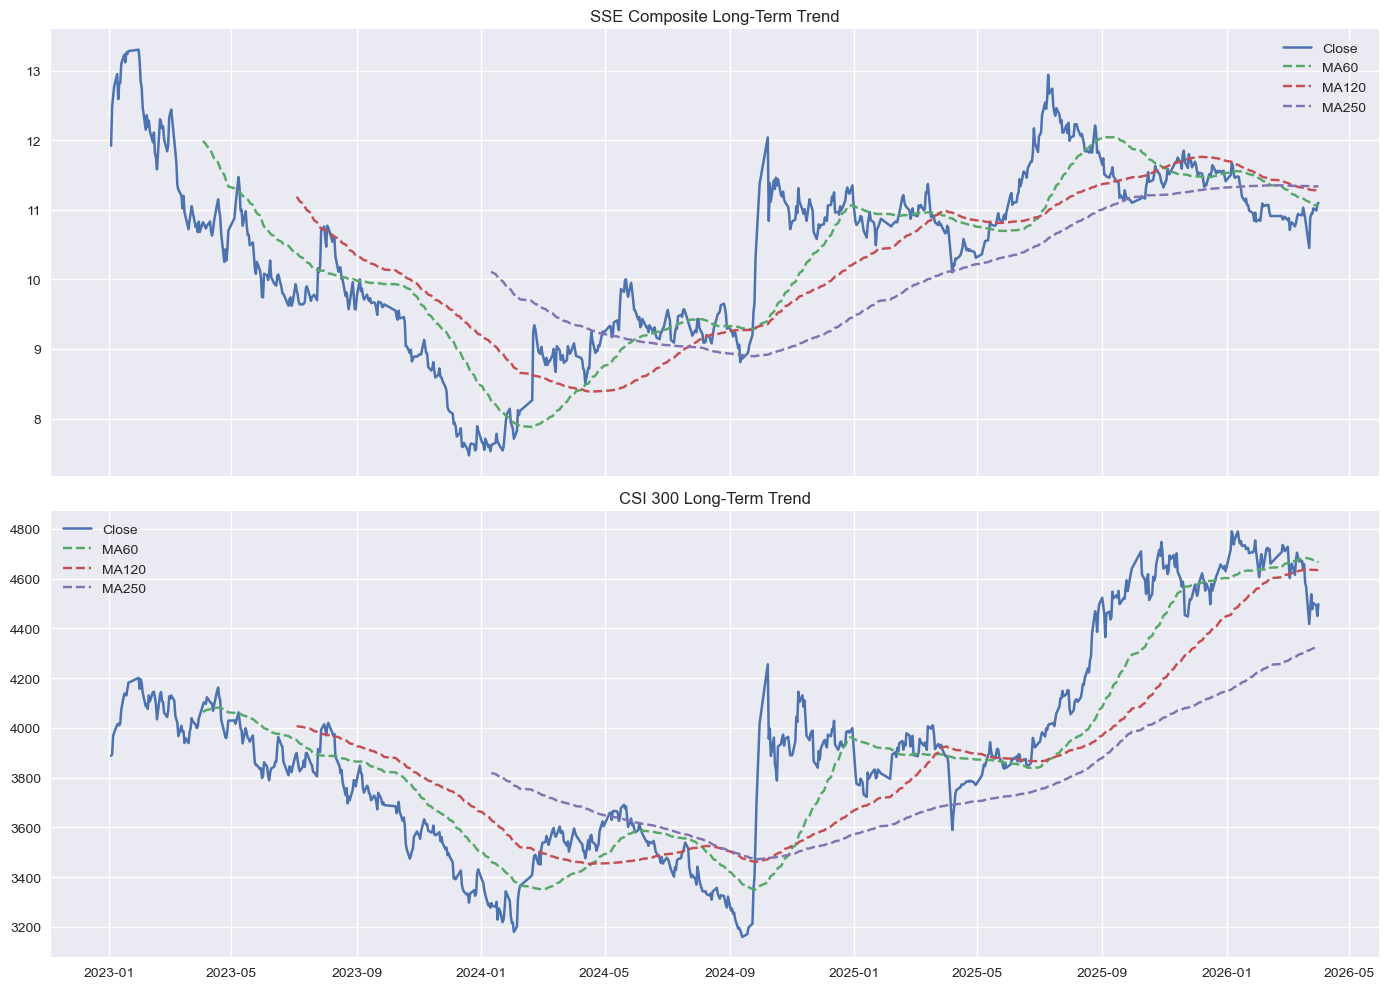

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, code in zip(axes, index_ids.keys()):
    df = index_data[code]
    ax.plot(df["日期"], df["收盘"], label="Close", linewidth=1.8)
    ax.plot(df["日期"], df["MA60"], label="MA60", linestyle="--")
    ax.plot(df["日期"], df["MA120"], label="MA120", linestyle="--")
    ax.plot(df["日期"], df["MA250"], label="MA250", linestyle="--")
    ax.set_title(f"{index_ids[code]} Long-Term Trend")
    ax.legend()

plt.tight_layout()
plt.show()


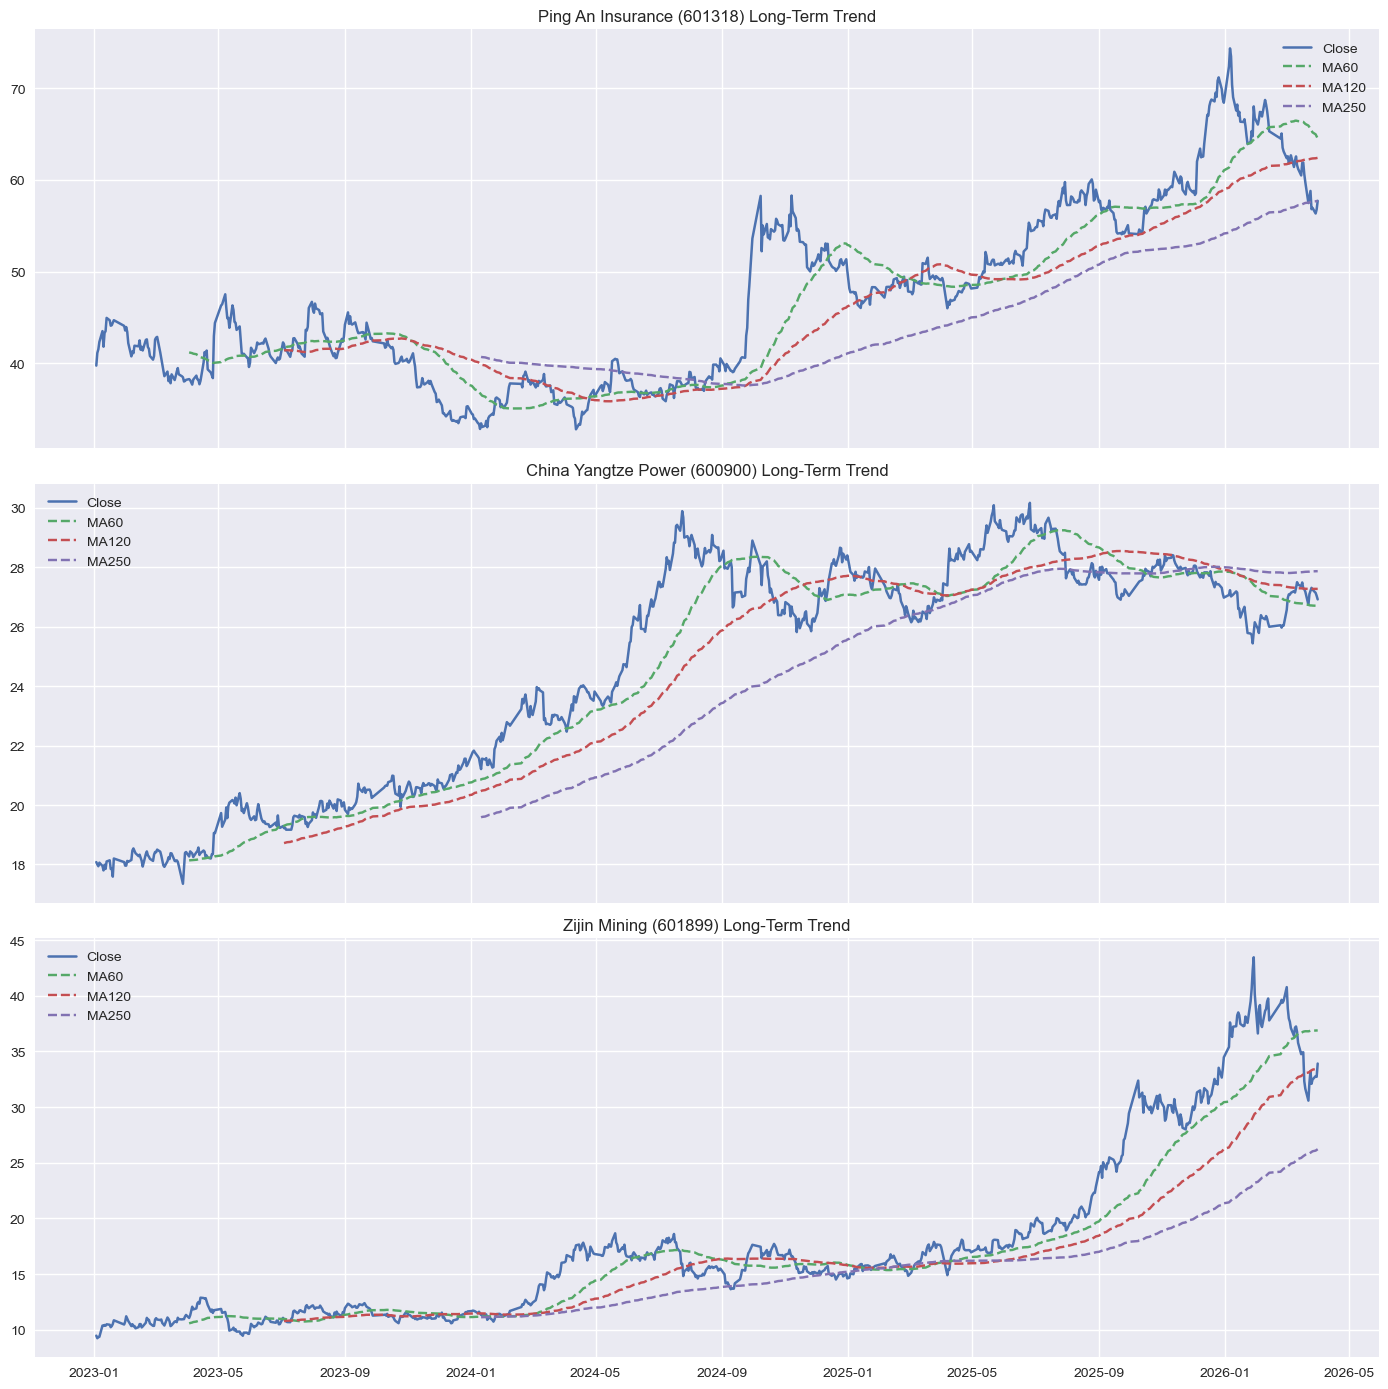

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

for ax, code in zip(axes, selected_stocks.keys()):
    df = stock_data[code]
    ax.plot(df["日期"], df["收盘"], label="Close", linewidth=1.8)
    ax.plot(df["日期"], df["MA60"], label="MA60", linestyle="--")
    ax.plot(df["日期"], df["MA120"], label="MA120", linestyle="--")
    ax.plot(df["日期"], df["MA250"], label="MA250", linestyle="--")
    ax.set_title(f"{selected_stocks[code]} ({code}) Long-Term Trend")
    ax.legend()

plt.tight_layout()
plt.show()


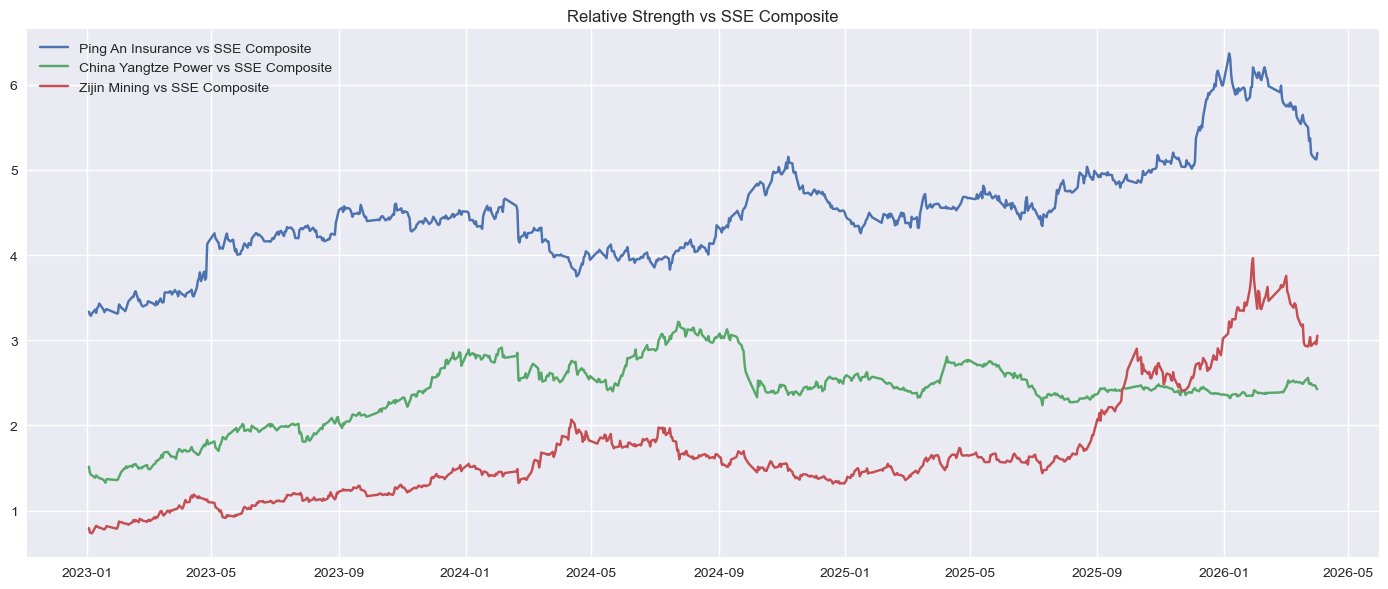

In [34]:
plt.figure(figsize=(14, 6))

for code, name in selected_stocks.items():
    df = relative_vs_sse[code]
    plt.plot(df["日期"], df["relative_strength_vs_sse"], label=f"{name} vs SSE Composite")

plt.title("Relative Strength vs SSE Composite")
plt.legend()
plt.tight_layout()
plt.show()


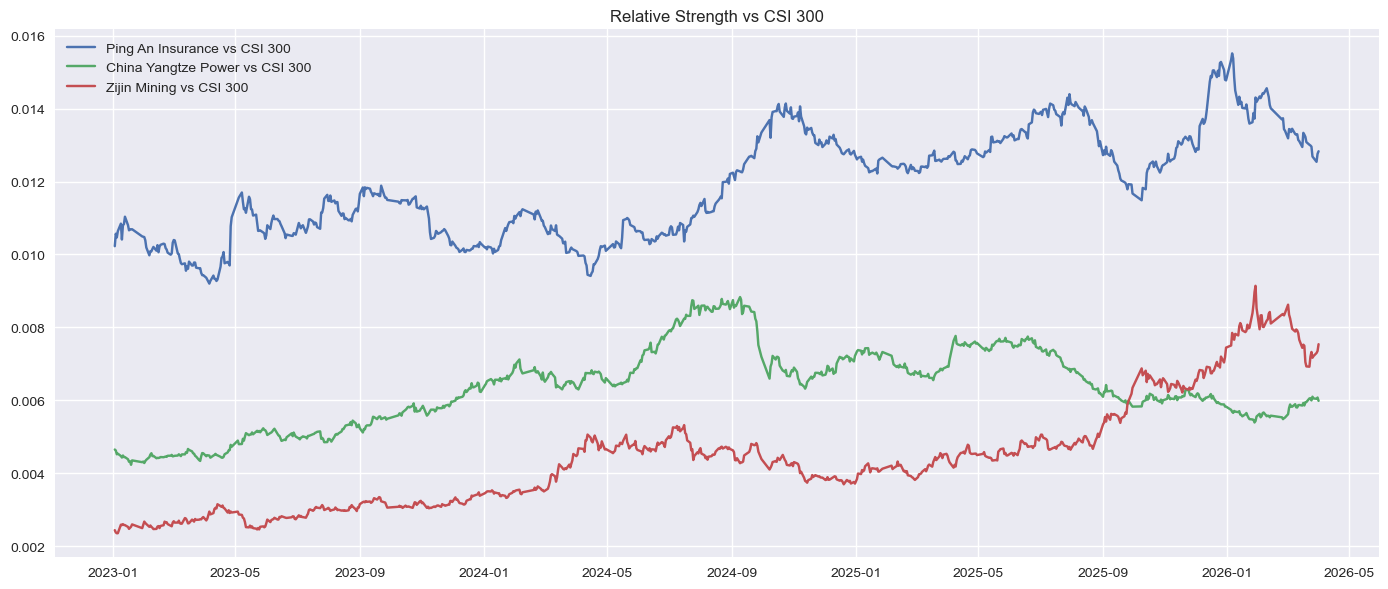

In [35]:
plt.figure(figsize=(14, 6))

for code, name in selected_stocks.items():
    df = relative_vs_csi300[code]
    plt.plot(df["日期"], df["relative_strength_vs_csi300"], label=f"{name} vs CSI 300")

plt.title("Relative Strength vs CSI 300")
plt.legend()
plt.tight_layout()
plt.show()
